# Lunar south-pole settlement: one-time launch estimate

This notebook estimates the **planned successful Earth-origin Starship/Super Heavy launches** needed to establish a four-person settlement capable of 180 days without resupply. It builds a bottom-up inventory, integer transport model, packable flight manifest, scenario analysis, Monte Carlo uncertainty, sensitivity ranking, and automated verification.

- Starship performance values are visible engineering assumptions, not verified specifications.
- Vehicle dry mass and in-space propellant are transport accounting, not settlement inventory.
- The baseline architecture uses uncrewed cargo Starships plus **one crew Starship**; no non-Starship launch dependency is assumed.

## 1. Runtime capability probe

Before modeling, we confirm the available numerical, tabular, plotting, testing, and file-writing capabilities. This also records the no-network/no-subprocess constraint under which the analysis is reproducible.

In [1]:
import sys, importlib.util, platform
from pathlib import Path

packages = ["numpy", "pandas", "matplotlib", "scipy", "sklearn"]
capabilities = []
for name in packages:
    spec = importlib.util.find_spec(name)
    if spec is not None:
        module = __import__(name)
        version = getattr(module, "__version__", "bundled")
        capabilities.append((name, True, version))
    else:
        capabilities.append((name, False, "—"))

import pandas as pd
capability_table = pd.DataFrame(capabilities, columns=["capability", "available", "version"])
capability_table.loc[len(capability_table)] = ["local file I/O", True, "stdlib pathlib"]
capability_table.loc[len(capability_table)] = ["network/subprocess/native compile", False, "excluded by runtime"]
print(f"Python: {sys.version.split()[0]} | Platform: {platform.system()} / {platform.machine()}")
capability_table

Python: 3.13.2 | Platform: Emscripten / wasm32


,capability,available,version
0,numpy,True,2.2.5
1,pandas,True,2.3.3
2,matplotlib,True,3.8.4
3,scipy,True,1.14.1
4,sklearn,True,1.7.0
5,local file I/O,True,stdlib pathlib
6,network/subprocess/native compile,False,excluded by runtime


The runtime provides the required scientific stack and local file output. Because no external verification is possible here, every consequential vehicle-performance number remains labeled as an **engineering assumption** rather than a cited fact.

## 2. Assumptions registry

The registry below is the model’s single source of truth. Low/base/high mean plausible modeling bounds; they are not confidence intervals. For parameters where “low” is operationally favorable (for example transfer loss), scenario mapping later explicitly chooses conservative/base/optimistic values rather than assuming that high always means conservative.

In [2]:
import math
import json
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path

SEED = 20250308
rng = np.random.default_rng(SEED)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")

assumption_rows = [
    # Mission and crew
    ("crew_size", "people", 4, 4, 4, "Fixed settlement complement", "known input"),
    ("strict_duration", "days", 180, 180, 180, "Required no-resupply occupancy", "known input"),
    ("reserve_days", "days", 20, 30, 45, "Consumable reserve beyond strict case", "engineering assumption"),
    # Daily gross consumables before recovery/ISRU
    ("food_rate", "kg/person-day", 1.70, 1.90, 2.20, "Food plus edible packaging allowance", "engineering assumption"),
    ("water_makeup_rate", "kg/person-day", 3.0, 4.5, 7.0, "Net potable/hygiene makeup after recycling", "engineering assumption"),
    ("oxygen_makeup_rate", "kg/person-day", 0.65, 0.84, 1.00, "Metabolic oxygen and operational loss makeup", "engineering assumption"),
    ("nitrogen_makeup_rate", "kg/person-day", 0.08, 0.15, 0.30, "Cabin leakage and repressurization allowance", "engineering assumption"),
    ("hygiene_medical_rate", "kg/person-day", 0.35, 0.55, 0.80, "Hygiene, medical, clothing, and waste consumables", "engineering assumption"),
    ("consumables_fixed", "t", 2.0, 3.0, 5.0, "Contingency gases, filters, salts, and communal stores", "engineering assumption"),
    # Transport
    ("surface_payload_cargo", "t/Starship", 80, 100, 125, "Usable landed cargo after mission-specific accommodations", "engineering assumption"),
    ("surface_payload_crew", "t/Starship", 10, 15, 20, "Settlement cargo carried with crew and crew systems", "engineering assumption"),
    ("tanker_net_propellant", "t/tanker", 100, 125, 150, "Transferable propellant arriving at depot before campaign losses", "engineering assumption"),
    ("propellant_per_lunar_ship", "t", 1050, 1200, 1400, "Nominal on-orbit load allocated per lunar-bound Starship", "engineering assumption"),
    ("transfer_loss", "fraction", 0.04, 0.08, 0.13, "Aggregate docking and transfer loss", "engineering assumption"),
    ("boiloff", "fraction", 0.02, 0.04, 0.08, "Storage and campaign boiloff", "engineering assumption"),
    ("propellant_reserve", "fraction", 0.08, 0.12, 0.18, "Mission propellant reserve above nominal requirement", "engineering assumption"),
    ("depot_capacity", "t", 1200, 1600, 2200, "Working propellant capacity per launched depot", "engineering assumption"),
    ("depot_reuse_cycles", "lunar ships/depot", 3, 8, 16, "Sequential lunar campaigns supported by one depot", "engineering assumption"),
    ("crew_starships", "launches", 1, 1, 1, "One direct crew landing vehicle", "architecture choice"),
    # Uncertainty/attempts
    ("launch_success_probability", "fraction", 0.94, 0.97, 0.99, "Optional expected-attempt calculation only", "engineering assumption"),
    ("integration_margin", "fraction", 0.10, 0.15, 0.22, "System-level growth after packaging", "engineering assumption"),
    ("packaging_fraction", "fraction", 0.06, 0.08, 0.12, "Crates, restraints, landing deployment interfaces", "engineering assumption"),
    ("general_spares_fraction", "fraction", 0.10, 0.15, 0.22, "Cross-cutting replacement units and repair stock", "engineering assumption"),
]
assumptions = pd.DataFrame(assumption_rows, columns=["parameter", "unit", "low", "base", "high", "rationale", "status"])
print(f"Registry: {len(assumptions)} parameters")
assumptions

Registry: 23 parameters


,parameter,unit,low,base,high,rationale,status
0,crew_size,people,4.00,4.00,4.00,Fixed settlement complement,known input
1,strict_duration,days,180.00,180.00,180.00,Required no-resupply occupancy,known input
2,reserve_days,days,20.00,30.00,45.00,Consumable reserve beyond strict case,engineering assumption
3,food_rate,kg/person-day,1.70,1.90,2.20,Food plus edible packaging allowance,engineering assumption
4,water_makeup_rate,kg/person-day,3.00,4.50,7.00,Net potable/hygiene makeup after recycling,engineering assumption
5,oxygen_makeup_rate,kg/person-day,0.65,0.84,1.00,Metabolic oxygen and operational loss makeup,engineering assumption
6,nitrogen_makeup_rate,kg/person-day,0.08,0.15,0.30,Cabin leakage and repressurization allowance,engineering assumption
7,hygiene_medical_rate,kg/person-day,0.35,0.55,0.80,"Hygiene, medical, clothing, and waste consumables",engineering assumption
8,consumables_fixed,t,2.00,3.00,5.00,"Contingency gases, filters, salts, and communa...",engineering assumption
9,surface_payload_cargo,t/Starship,80.00,100.00,125.00,Usable landed cargo after mission-specific acc...,engineering assumption


## 3. Bottom-up settlement inventory

Hardware is represented as discrete manifest units. Two independently habitable pressure modules, three life-support trains for a two-train operating requirement, three water-recovery trains for two required, dual emergency power units, dual communications, and six suits for four occupants implement N+1 resilience. Bulk consumables and cross-cutting margin layers remain divisible.

In [3]:
# Add the explicit design-contingency layer to the registry.
assumptions.loc[len(assumptions)] = (
    "design_contingency", "fraction", 0.05, 0.08, 0.12,
    "Early-design mass growth before packaging and integration", "engineering assumption"
)

item_specs = [
    # item, category, quantity, unit mass t, divisible, resilience note
    ("Pressurized habitat module", "Habitation", 2, 28.0, False, "Two independently isolatable volumes"),
    ("Radiation storm-shelter kit", "Habitation", 1, 20.0, False, "Water/polymer shielding; shelter remains usable after module isolation"),
    ("Airlock and dust-control module", "Habitation", 2, 8.0, False, "N+1 airlock path"),
    ("Thermal-control train", "Habitation", 3, 4.5, False, "2 required + 1 spare"),
    ("Life-support processing train", "Life support", 3, 8.0, False, "2 required + 1 spare"),
    ("Water-recovery train", "Life support", 3, 5.0, False, "2 required + 1 spare"),
    ("Atmosphere storage/control skid", "Life support", 2, 4.0, False, "N+1 control and isolation"),
    ("Waste stabilization unit", "Life support", 2, 3.5, False, "N+1 waste path"),
    ("Solar generation wing", "Power", 4, 12.0, False, "Multiple independently switched wings"),
    ("Battery storage bank", "Power", 3, 15.0, False, "2 required + 1 spare bank"),
    ("Emergency fission power unit", "Power", 2, 20.0, False, "N+1 emergency units; conceptual mass allowance"),
    ("Power distribution/microgrid skid", "Power", 2, 8.0, False, "N+1 distribution paths"),
    ("High-gain Earth communications terminal", "Comms/navigation", 2, 4.0, False, "N+1 Earth links"),
    ("Local navigation/relay beacon set", "Comms/navigation", 2, 2.5, False, "Redundant local positioning"),
    ("Compute, control, and timing rack", "Comms/navigation", 3, 1.5, False, "2 active + 1 cold spare"),
    ("ISRU volatile-processing train", "ISRU", 2, 18.0, False, "One production train plus full spare"),
    ("Regolith excavator", "ISRU", 2, 11.0, False, "N+1 feedstock handling"),
    ("ISRU product storage skid", "ISRU", 2, 5.0, False, "Isolatable duplicate storage"),
    ("Pressurized surface rover", "Mobility/deployment", 2, 12.0, False, "Rescue capability if one rover fails"),
    ("Unpressurized utility rover", "Mobility/deployment", 2, 5.0, False, "N+1 local hauling"),
    ("Cargo handler/teleloader", "Mobility/deployment", 2, 9.0, False, "N+1 unloading and construction"),
    ("Deployable crane", "Mobility/deployment", 2, 7.0, False, "N+1 lift capability"),
    ("Berm/shielding construction dozer", "Mobility/deployment", 2, 10.0, False, "N+1 shielding construction"),
    ("EVA suit package", "EVA/tools", 6, 0.35, False, "4 operational + 2 spares"),
    ("Suit maintenance/charging bench", "EVA/tools", 2, 1.5, False, "N+1 service benches"),
    ("Workshop and additive repair cell", "EVA/tools", 2, 5.0, False, "N+1 repair paths"),
    ("Science/medical laboratory module", "Medical/science", 1, 10.0, False, "Includes isolation berth and diagnostics"),
    ("Medical equipment cache", "Medical/science", 2, 1.5, False, "Split caches prevent single loss"),
    ("Fire suppression/rescue cache", "Safety", 2, 2.5, False, "Split emergency caches"),
    ("Landing-zone and cable kit", "Site infrastructure", 2, 5.0, False, "Two separated utility corridors"),
]
items = pd.DataFrame(item_specs, columns=["item", "category", "quantity", "unit_mass_t", "divisible", "resilience"])
items["base_mass_t"] = items["quantity"] * items["unit_mass_t"]
category_hardware = items.groupby("category", as_index=False)["base_mass_t"].sum().sort_values("base_mass_t", ascending=False)
print(f"Discrete equipment: {int(items.quantity.sum())} units across {len(items)} line items")
print(f"Base hardware before spares/margins: {items.base_mass_t.sum():.1f} t")
category_hardware

Discrete equipment: 69 units across 30 line items
Base hardware before spares/margins: 523.1 t


,category,base_mass_t
7,Power,149.00
2,Habitation,105.50
6,Mobility/deployment,86.00
3,ISRU,68.00
4,Life support,54.00
0,Comms/navigation,17.50
1,EVA/tools,15.10
5,Medical/science,13.00
9,Site infrastructure,10.00
8,Safety,5.00


### 3.1 Consumables, ISRU policy, and explicit margin layers

For water and oxygen only, credited ISRU production begins after a commissioning delay. The **no-credit** case carries the full mission requirement; partial and mature cases can reduce only post-commissioning water/oxygen makeup. Food, atmospheric nitrogen, hygiene/medical stores, and fixed contingency stores are never reduced by ISRU.

In [4]:
# Register every discrete item mass and quantity rather than hiding them in code.
for row in items.itertuples(index=False):
    key = row.item.lower().replace("/", "_").replace(" ", "_").replace("-", "_")
    assumptions.loc[len(assumptions)] = (
        f"{key}_unit_mass", "t/unit", round(row.unit_mass_t * 0.85, 3), row.unit_mass_t,
        round(row.unit_mass_t * 1.20, 3), row.resilience, "engineering assumption"
    )
    assumptions.loc[len(assumptions)] = (
        f"{key}_quantity", "units", row.quantity, row.quantity, row.quantity,
        row.resilience, "architecture choice"
    )

extra_rows = [
    ("partial_isru_commission_day", "day", 45, 60, 90, "Credit starts only after demonstrated production", "engineering assumption"),
    ("partial_isru_replacement", "fraction", 0.35, 0.50, 0.65, "Water/oxygen makeup replaced after commissioning", "engineering assumption"),
    ("mature_isru_commission_day", "day", 20, 30, 45, "Optimistic established commissioning performance", "engineering assumption"),
    ("mature_isru_replacement", "fraction", 0.70, 0.80, 0.90, "Optimistic water/oxygen replacement", "engineering assumption"),
    ("hardware_mass_factor", "fraction", 0.88, 1.00, 1.18, "Correlated maturity/growth uncertainty across equipment", "engineering assumption"),
]
for row in extra_rows:
    assumptions.loc[len(assumptions)] = row

A = assumptions.set_index("parameter")
def av(name, column="base"):
    return float(A.loc[name, column])

ISRU_POLICIES = {
    "no_credit": {"commission_day": math.inf, "replacement": 0.0},
    "partial": {"commission_day": av("partial_isru_commission_day"), "replacement": av("partial_isru_replacement")},
    "mature": {"commission_day": av("mature_isru_commission_day"), "replacement": av("mature_isru_replacement")},
}

def consumables_breakdown(days, crew=4, isru_policy="no_credit", values=None):
    get = (lambda n: values[n]) if values is not None else (lambda n: av(n))
    policy = ISRU_POLICIES[isru_policy].copy()
    if values is not None and isru_policy != "no_credit":
        prefix = "partial" if isru_policy == "partial" else "mature"
        policy = {"commission_day": values[f"{prefix}_isru_commission_day"],
                  "replacement": values[f"{prefix}_isru_replacement"]}
    credited_days = max(0.0, days - policy["commission_day"])
    retained_fraction_days = days - credited_days * policy["replacement"]
    return {
        "Food": crew * days * get("food_rate") / 1000,
        "Water makeup": crew * retained_fraction_days * get("water_makeup_rate") / 1000,
        "Oxygen makeup": crew * retained_fraction_days * get("oxygen_makeup_rate") / 1000,
        "Nitrogen makeup": crew * days * get("nitrogen_makeup_rate") / 1000,
        "Hygiene/medical/waste": crew * days * get("hygiene_medical_rate") / 1000,
        "Fixed survival stores": get("consumables_fixed"),
    }

def build_mass_budget(days=210, isru_policy="no_credit", values=None):
    get = (lambda n: values[n]) if values is not None else (lambda n: av(n))
    hw_factor = get("hardware_mass_factor")
    hardware = items.groupby("category")["base_mass_t"].sum() * hw_factor
    rows = [{"layer": "Equipment", "category": k, "mass_t": v} for k, v in hardware.items()]
    hardware_total = hardware.sum()
    design = hardware_total * get("design_contingency")
    spares = hardware_total * get("general_spares_fraction")
    rows += [
        {"layer": "Contingency", "category": "Design contingency", "mass_t": design},
        {"layer": "Spares", "category": "Cross-cutting spares", "mass_t": spares},
    ]
    cons = consumables_breakdown(days, int(get("crew_size")), isru_policy, values)
    rows += [{"layer": "Consumables", "category": k, "mass_t": v} for k, v in cons.items()]
    subtotal = sum(r["mass_t"] for r in rows)
    packaging = subtotal * get("packaging_fraction")
    rows.append({"layer": "Packaging", "category": "Packaging/deployment interfaces", "mass_t": packaging})
    integration = (subtotal + packaging) * get("integration_margin")
    rows.append({"layer": "Integration", "category": "System integration margin", "mass_t": integration})
    return pd.DataFrame(rows)

budget_comparison = []
for days, reserve_case in [(180, "Strict 180-day"), (210, "180 + 30-day reserve")]:
    for policy in ISRU_POLICIES:
        b = build_mass_budget(days, policy)
        budget_comparison.append({"case": reserve_case, "ISRU policy": policy, "delivered mass t": b.mass_t.sum(),
                                  "consumables t": b.loc[b.layer == "Consumables", "mass_t"].sum()})
budget_comparison = pd.DataFrame(budget_comparison)
print(f"Registry expanded to {len(assumptions)} rows; all 30 discrete line items are represented.")
budget_comparison

Registry expanded to 89 rows; all 30 discrete line items are represented.


,case,ISRU policy,delivered mass t,consumables t
0,Strict 180-day,no_credit,809.95,8.72
1,Strict 180-day,partial,808.35,7.44
2,Strict 180-day,mature,806.76,6.15
3,180 + 30-day reserve,no_credit,811.13,9.67
4,180 + 30-day reserve,partial,809.14,8.07
5,180 + 30-day reserve,mature,807.31,6.59


In [6]:
def split_bulk(name, category, mass_t, max_piece=20.0):
    """Represent divisible cargo in manageable source parcels."""
    n = max(1, math.ceil(mass_t / max_piece))
    return [{"item": name, "category": category, "mass_t": mass_t / n, "divisible": True,
             "unit_id": f"{name} parcel {i+1}/{n}"} for i in range(n)]

def manifest_units(days=210, isru_policy="no_credit", values=None):
    get = (lambda n: values[n]) if values is not None else (lambda n: av(n))
    hw_factor = get("hardware_mass_factor")
    units = []
    for row in items.itertuples(index=False):
        for i in range(int(row.quantity)):
            units.append({"item": row.item, "category": row.category,
                          "mass_t": row.unit_mass_t * hw_factor, "divisible": False,
                          "unit_id": f"{row.item} {i+1}/{int(row.quantity)}"})
    budget = build_mass_budget(days, isru_policy, values)
    for row in budget.loc[budget.layer != "Equipment"].itertuples(index=False):
        units.extend(split_bulk(row.category, row.layer, row.mass_t))
    return units

def pack_manifest(days=210, isru_policy="no_credit", values=None):
    get = (lambda n: values[n]) if values is not None else (lambda n: av(n))
    cargo_cap, crew_cap = get("surface_payload_cargo"), get("surface_payload_crew")
    units = manifest_units(days, isru_policy, values)
    crew_priority_categories = {"EVA/tools", "Medical/science", "Comms/navigation", "Safety"}
    crew_candidates = sorted([u for u in units if (not u["divisible"]) and u["category"] in crew_priority_categories],
                             key=lambda u: u["mass_t"])
    crew_load, crew_mass = [], 0.0
    for u in crew_candidates:
        if crew_mass + u["mass_t"] <= crew_cap + 1e-9:
            crew_load.append(u); crew_mass += u["mass_t"]
    selected = {id(u) for u in crew_load}
    discrete = sorted([u for u in units if id(u) not in selected and not u["divisible"]],
                      key=lambda u: u["mass_t"], reverse=True)
    divisible = [u for u in units if u["divisible"]]
    bins = []
    # Best-fit decreasing for true indivisible units.
    for u in discrete:
        feasible = [b for b in bins if b["mass_t"] + u["mass_t"] <= cargo_cap + 1e-9]
        if feasible:
            b = max(feasible, key=lambda x: x["mass_t"])
            b["items"].append(u); b["mass_t"] += u["mass_t"]
        else:
            if u["mass_t"] > cargo_cap + 1e-9:
                raise ValueError(f"Indivisible item exceeds cargo capacity: {u['unit_id']}")
            bins.append({"items": [u], "mass_t": u["mass_t"]})
    # Divisible stores/margins may be split across remaining flight capacity.
    for source in divisible:
        remaining = source["mass_t"]
        part = 1
        while remaining > 1e-9:
            feasible = [b for b in bins if b["mass_t"] < cargo_cap - 1e-9]
            if feasible:
                b = max(feasible, key=lambda x: x["mass_t"])
            else:
                b = {"items": [], "mass_t": 0.0}; bins.append(b)
            take = min(remaining, cargo_cap - b["mass_t"])
            piece = {**source, "mass_t": take, "unit_id": f"{source['unit_id']} part {part}"}
            b["items"].append(piece); b["mass_t"] += take
            remaining -= take; part += 1
    records = []
    for u in crew_load:
        records.append({"flight": "Crew-1", "flight_type": "crew", **u})
    for i, b in enumerate(bins, 1):
        for u in b["items"]:
            records.append({"flight": f"Cargo-{i}", "flight_type": "cargo", **u})
    return pd.DataFrame(records), len(bins)

def launch_accounting(cargo_ships, values=None, crew_ships=None):
    get = (lambda n: values[n]) if values is not None else (lambda n: av(n))
    crew = int(get("crew_starships") if crew_ships is None else crew_ships)
    lunar_ships = int(cargo_ships + crew)
    loss = get("transfer_loss") + get("boiloff")
    if loss >= 1:
        raise ValueError("Combined transfer loss and boiloff must be below 1")
    prop_per_ship_uplink = get("propellant_per_lunar_ship") * (1 + get("propellant_reserve")) / (1 - loss)
    total_prop = lunar_ships * prop_per_ship_uplink
    tankers = math.ceil(total_prop / get("tanker_net_propellant"))
    capacity_depots = math.ceil(prop_per_ship_uplink / get("depot_capacity"))
    cycle_depots = math.ceil(lunar_ships / get("depot_reuse_cycles"))
    depots = max(capacity_depots, cycle_depots)
    total = int(cargo_ships + crew + tankers + depots)
    return {"cargo": int(cargo_ships), "crew": crew, "lunar_ships": lunar_ships,
            "tankers": tankers, "depots": depots, "total": total,
            "propellant_per_lunar_ship_t": prop_per_ship_uplink,
            "total_depot_throughput_t": total_prop}

baseline_manifest, baseline_cargo_count = pack_manifest(210, "no_credit")
baseline_launches = launch_accounting(baseline_cargo_count)
flight_summary = baseline_manifest.groupby(["flight", "flight_type"], as_index=False).agg(
    manifested_mass_t=("mass_t", "sum"), line_items=("unit_id", "count"))
flight_summary["capacity_t"] = flight_summary.flight_type.map({"cargo": av("surface_payload_cargo"), "crew": av("surface_payload_crew")})
flight_summary["utilization"] = flight_summary.manifested_mass_t / flight_summary.capacity_t
print("Repaired baseline integer arithmetic:", baseline_launches)
flight_summary

Repaired baseline integer arithmetic: {'cargo': 8, 'crew': 1, 'lunar_ships': 9, 'tankers': 110, 'depots': 2, 'total': 121, 'propellant_per_lunar_ship_t': 1527.2727272727275, 'total_depot_throughput_t': 13745.454545454548}


,flight,flight_type,manifested_mass_t,line_items,capacity_t,utilization
0,Cargo-1,cargo,100.00,5,100.00,1.00
1,Cargo-2,cargo,100.00,7,100.00,1.00
2,Cargo-3,cargo,100.00,10,100.00,1.00
3,Cargo-4,cargo,100.00,12,100.00,1.00
4,Cargo-5,cargo,100.00,20,100.00,1.00
5,Cargo-6,cargo,100.00,11,100.00,1.00
6,Cargo-7,cargo,100.00,12,100.00,1.00
7,Cargo-8,cargo,98.53,6,100.00,0.99
8,Crew-1,crew,12.60,13,15.00,0.84


In [7]:
MASS_ADVERSE_HIGH = {"food_rate", "water_makeup_rate", "oxygen_makeup_rate", "nitrogen_makeup_rate",
                     "hygiene_medical_rate", "consumables_fixed", "integration_margin", "packaging_fraction",
                     "general_spares_fraction", "design_contingency", "hardware_mass_factor"}
TRANSPORT_ADVERSE_HIGH = {"propellant_per_lunar_ship", "transfer_loss", "boiloff", "propellant_reserve"}
TRANSPORT_ADVERSE_LOW = {"surface_payload_cargo", "surface_payload_crew", "tanker_net_propellant",
                         "depot_capacity", "depot_reuse_cycles"}

def scenario_values(name):
    vals = A["base"].astype(float).to_dict()
    if name == "baseline":
        return vals
    if name == "conservative":
        for p in MASS_ADVERSE_HIGH | TRANSPORT_ADVERSE_HIGH:
            vals[p] = av(p, "high")
        for p in TRANSPORT_ADVERSE_LOW:
            vals[p] = av(p, "low")
    elif name == "optimistic":
        for p in MASS_ADVERSE_HIGH | TRANSPORT_ADVERSE_HIGH:
            vals[p] = av(p, "low")
        for p in TRANSPORT_ADVERSE_LOW:
            vals[p] = av(p, "high")
    else:
        raise KeyError(name)
    return vals

scenario_rows = []
for scenario, policy in [("conservative", "no_credit"), ("baseline", "no_credit"), ("optimistic", "mature")]:
    vals = scenario_values(scenario)
    mfest, n_cargo = pack_manifest(210, policy, vals)
    la = launch_accounting(n_cargo, vals)
    scenario_rows.append({"scenario": scenario, "ISRU policy": policy,
                          "delivered mass t": mfest.mass_t.sum(), **la})
scenario_table = pd.DataFrame(scenario_rows)

# Required strict and reserve comparison at baseline, with no ISRU survival credit.
mission_case_rows = []
for days, label in [(180, "strict 180-day"), (210, "180 + 30 reserve")]:
    mf, nc = pack_manifest(days, "no_credit")
    la = launch_accounting(nc)
    mission_case_rows.append({"mission case": label, "delivered mass t": mf.mass_t.sum(), **la})
mission_case_table = pd.DataFrame(mission_case_rows)

print("Conservative / baseline / optimistic:")
display(scenario_table[["scenario", "ISRU policy", "delivered mass t", "cargo", "crew", "tankers", "depots", "total"]])
print("Strict versus required 30-day reserve case:")
mission_case_table[["mission case", "delivered mass t", "cargo", "crew", "tankers", "depots", "total"]]

Conservative / baseline / optimistic:


,scenario,ISRU policy,delivered mass t,cargo,crew,tankers,depots,total
0,conservative,no_credit,"1,149.99",15,1,335,6,357
1,baseline,no_credit,811.13,8,1,110,2,121
2,optimistic,mature,622.80,5,1,49,1,56


Strict versus required 30-day reserve case:


,mission case,delivered mass t,cargo,crew,tankers,depots,total
0,strict 180-day,809.95,8,1,110,2,121
1,180 + 30 reserve,811.13,8,1,110,2,121


In [8]:
from scipy.stats import spearmanr

N_MC = 20_000
mc_params = [
    "food_rate", "water_makeup_rate", "oxygen_makeup_rate", "nitrogen_makeup_rate", "hygiene_medical_rate",
    "consumables_fixed", "surface_payload_cargo", "surface_payload_crew", "tanker_net_propellant",
    "propellant_per_lunar_ship", "transfer_loss", "boiloff", "propellant_reserve", "depot_capacity",
    "depot_reuse_cycles", "integration_margin", "packaging_fraction", "general_spares_fraction",
    "design_contingency", "hardware_mass_factor"
]
mc_samples = {}
for p in mc_params:
    mc_samples[p] = rng.triangular(av(p, "low"), av(p, "base"), av(p, "high"), N_MC)

base_hw_total = items.base_mass_t.sum()
elig_base_masses = []
all_unit_base_masses = []
for row in items.itertuples(index=False):
    for _ in range(int(row.quantity)):
        all_unit_base_masses.append(row.unit_mass_t)
        if row.category in {"EVA/tools", "Medical/science", "Comms/navigation", "Safety"}:
            elig_base_masses.append(row.unit_mass_t)
elig_base_masses = sorted(elig_base_masses)
all_unit_base_masses = sorted(all_unit_base_masses, reverse=True)

def scalar_mc_case(i):
    s = {p: mc_samples[p][i] for p in mc_params}
    hf = s["hardware_mass_factor"]
    hardware = base_hw_total * hf
    cons = (4 * 210 * (s["food_rate"] + s["water_makeup_rate"] + s["oxygen_makeup_rate"] +
                       s["nitrogen_makeup_rate"] + s["hygiene_medical_rate"]) / 1000 + s["consumables_fixed"])
    subtotal = hardware * (1 + s["design_contingency"] + s["general_spares_fraction"]) + cons
    total_mass = subtotal * (1 + s["packaging_fraction"]) * (1 + s["integration_margin"])
    crew_load = 0.0
    crew_selected = []
    for m0 in elig_base_masses:
        m = m0 * hf
        if crew_load + m <= s["surface_payload_crew"] + 1e-9:
            crew_load += m; crew_selected.append(m0)
    # Best-fit discrete equipment after removing the units selected for crew flight.
    selected_pool = list(crew_selected)
    remaining_discrete = []
    for m0 in all_unit_base_masses:
        if m0 in selected_pool:
            selected_pool.remove(m0)
        else:
            remaining_discrete.append(m0 * hf)
    bins = []
    cap = s["surface_payload_cargo"]
    for mass in remaining_discrete:
        feasible_idx = [j for j, used in enumerate(bins) if used + mass <= cap + 1e-9]
        if feasible_idx:
            j = max(feasible_idx, key=lambda k: bins[k]); bins[j] += mass
        else:
            bins.append(mass)
    cargo = max(len(bins), math.ceil(max(0, total_mass - crew_load) / cap - 1e-12))
    lunar = cargo + 1
    prop_ship = s["propellant_per_lunar_ship"] * (1 + s["propellant_reserve"]) / (1 - s["transfer_loss"] - s["boiloff"])
    tankers = math.ceil(lunar * prop_ship / s["tanker_net_propellant"] - 1e-12)
    depots = max(math.ceil(prop_ship / s["depot_capacity"] - 1e-12),
                 math.ceil(lunar / s["depot_reuse_cycles"] - 1e-12))
    return total_mass, crew_load, cargo, tankers, depots, cargo + 1 + tankers + depots

mc_result_array = np.array([scalar_mc_case(i) for i in range(N_MC)])
mc_results = pd.DataFrame(mc_result_array, columns=["mass_t", "crew_cargo_t", "cargo", "tankers", "depots", "total"])
for c in ["cargo", "tankers", "depots", "total"]:
    mc_results[c] = mc_results[c].astype(int)
quantiles = mc_results["total"].quantile([0.10, 0.50, 0.90], interpolation="nearest").astype(int)
launch_distribution = mc_results.total.value_counts().sort_index().rename_axis("launches").reset_index(name="cases")
launch_distribution["probability"] = launch_distribution.cases / N_MC
print(f"Seed={SEED:,}; cases={N_MC:,}; total-launch min/max={mc_results.total.min()}/{mc_results.total.max()}")
print(f"P10={quantiles.loc[0.10]}, P50={quantiles.loc[0.50]}, P90={quantiles.loc[0.90]}")
mc_results[["mass_t", "cargo", "tankers", "depots", "total"]].describe(percentiles=[.1, .5, .9])

Seed=20,250,308; cases=20,000; total-launch min/max=76/232
P10=112, P50=134, P90=161


,mass_t,cargo,tankers,depots,total
count,"20,000.00","20,000.00","20,000.00","20,000.00","20,000.00"
mean,846.05,8.75,124.32,1.81,135.88
std,57.80,1.00,18.36,0.52,19.17
min,688.15,6.00,68.00,1.00,76.00
10%,772.55,8.00,102.00,1.00,112.00
50%,843.51,9.00,123.00,2.00,134.00
90%,924.20,10.00,149.00,2.00,161.00
max,"1,047.31",13.00,217.00,4.00,232.00


In [9]:
def evaluate_values(vals, days=210, policy="no_credit"):
    mf, nc = pack_manifest(days, policy, vals)
    la = launch_accounting(nc, vals)
    return mf.mass_t.sum(), la

sensitivity_rows = []
base_vals = scenario_values("baseline")
_, base_la = evaluate_values(base_vals)
for p in mc_params:
    low_vals, high_vals = base_vals.copy(), base_vals.copy()
    low_vals[p], high_vals[p] = av(p, "low"), av(p, "high")
    low_mass, low_la = evaluate_values(low_vals)
    high_mass, high_la = evaluate_values(high_vals)
    rho, _ = spearmanr(mc_samples[p], mc_results.total)
    sensitivity_rows.append({
        "parameter": p, "low total": low_la["total"], "base total": base_la["total"],
        "high total": high_la["total"], "low cargo": low_la["cargo"], "high cargo": high_la["cargo"],
        "low tankers": low_la["tankers"], "high tankers": high_la["tankers"],
        "range launches": abs(high_la["total"] - low_la["total"]), "Spearman rho": rho,
        "crosses integer boundary": low_la["total"] != high_la["total"]
    })
sensitivity = pd.DataFrame(sensitivity_rows).sort_values(
    ["range launches", "Spearman rho"], ascending=[False, False]).reset_index(drop=True)
top_five = sensitivity.head(5).copy()
print(f"{sensitivity['crosses integer boundary'].sum()} of {len(sensitivity)} varied assumptions cross at least one total-launch boundary.")
top_five

15 of 20 varied assumptions cross at least one total-launch boundary.


,parameter,low total,base total,high total,low cargo,high cargo,low tankers,high tankers,range launches,Spearman rho,crosses integer boundary
0,tanker_net_propellant,149,121,103,8,8,138,92,46,-0.53,True
1,surface_payload_cargo,148,121,107,10,7,135,98,41,-0.53,True
2,propellant_per_lunar_ship,108,121,140,8,8,97,129,32,0.37,True
3,hardware_mass_factor,121,121,148,8,10,110,135,27,0.36,True
4,general_spares_fraction,121,121,135,8,9,110,123,14,0.13,True


In [10]:
def pack_all_cargo(days=210, isru_policy="no_credit", values=None):
    get = (lambda n: values[n]) if values is not None else (lambda n: av(n))
    cap = get("surface_payload_cargo")
    units = manifest_units(days, isru_policy, values)
    discrete = sorted([u for u in units if not u["divisible"]], key=lambda u: u["mass_t"], reverse=True)
    divisible = [u for u in units if u["divisible"]]
    bins = []
    for u in discrete:
        feasible = [b for b in bins if b["mass_t"] + u["mass_t"] <= cap + 1e-9]
        if feasible:
            b = max(feasible, key=lambda x: x["mass_t"]); b["items"].append(u); b["mass_t"] += u["mass_t"]
        else:
            bins.append({"items": [u], "mass_t": u["mass_t"]})
    for source in divisible:
        rem, part = source["mass_t"], 1
        while rem > 1e-9:
            feasible = [b for b in bins if b["mass_t"] < cap - 1e-9]
            b = max(feasible, key=lambda x: x["mass_t"]) if feasible else {"items": [], "mass_t": 0.0}
            if not feasible: bins.append(b)
            take = min(rem, cap - b["mass_t"])
            b["items"].append({**source, "mass_t": take, "unit_id": f"{source['unit_id']} part {part}"})
            b["mass_t"] += take; rem -= take; part += 1
    records = [{"flight": f"Cargo-{i}", "flight_type": "cargo", **u}
               for i, b in enumerate(bins, 1) for u in b["items"]]
    return pd.DataFrame(records), len(bins)

checks = []
def check(name, condition, detail):
    checks.append({"check": name, "status": "PASS" if bool(condition) else "FAIL", "detail": detail})

baseline_budget = build_mass_budget(210, "no_credit")
check("Subsystem masses reconcile", np.isclose(baseline_budget.mass_t.sum(), baseline_manifest.mass_t.sum(), atol=1e-8),
      f"budget={baseline_budget.mass_t.sum():.6f} t; manifest={baseline_manifest.mass_t.sum():.6f} t")
max_over = (flight_summary.manifested_mass_t - flight_summary.capacity_t).max()
check("Manifest capacity", max_over <= 1e-8, f"maximum overage={max_over:.9f} t")
category_sum = baseline_launches["cargo"] + baseline_launches["crew"] + baseline_launches["tankers"] + baseline_launches["depots"]
check("Launch categories sum", category_sum == baseline_launches["total"], f"categories={category_sum}; headline={baseline_launches['total']}")

payload_totals = []
for cap in np.linspace(80, 125, 10):
    vals = base_vals.copy(); vals["surface_payload_cargo"] = float(cap)
    _, la = evaluate_values(vals)
    payload_totals.append(la["total"])
check("Payload monotonicity", all(a >= b for a, b in zip(payload_totals, payload_totals[1:])),
      f"totals from 80→125 t payload: {payload_totals}")

crew_masses = []
for crew in [4, 5, 6]:
    vals = base_vals.copy(); vals["crew_size"] = crew
    crew_masses.append(build_mass_budget(210, "no_credit", vals).mass_t.sum())
check("Crew-size mass monotonicity", all(a <= b for a, b in zip(crew_masses, crew_masses[1:])), f"masses={np.round(crew_masses, 3).tolist()}")
duration_masses = [build_mass_budget(d, "no_credit").mass_t.sum() for d in [180, 210, 240]]
check("Duration mass monotonicity", all(a <= b for a, b in zip(duration_masses, duration_masses[1:])), f"masses={np.round(duration_masses, 3).tolist()}")

vals_lo, vals_hi = base_vals.copy(), base_vals.copy()
vals_lo["tanker_net_propellant"], vals_hi["tanker_net_propellant"] = av("tanker_net_propellant", "low"), av("tanker_net_propellant", "high")
mass_lo = build_mass_budget(210, "no_credit", vals_lo).mass_t.sum()
mass_hi = build_mass_budget(210, "no_credit", vals_hi).mass_t.sum()
transport_terms_absent = not baseline_manifest.category.astype(str).str.contains("orbital propellant|tanker", case=False, regex=True).any()
check("No propellant/cargo double count", np.isclose(mass_lo, mass_hi) and transport_terms_absent,
      f"settlement mass invariant to tanker delivery: {mass_lo:.3f}={mass_hi:.3f} t; transport propellant tracked separately")

infra_manifest, infra_cargo = pack_all_cargo(210, "no_credit")
infra_launches = launch_accounting(infra_cargo, crew_ships=0)
check("Infrastructure-only inventory complete", np.isclose(infra_manifest.mass_t.sum(), baseline_budget.mass_t.sum()),
      f"all-cargo manifest={infra_manifest.mass_t.sum():.3f} t")

check_table = pd.DataFrame(checks)
print(f"Verification: {(check_table.status == 'PASS').sum()}/{len(check_table)} checks passed")
print(f"Infrastructure-only: {infra_launches['total']} = {infra_launches['cargo']} cargo + {infra_launches['tankers']} tanker + {infra_launches['depots']} depot")
print(f"Crew-inclusive: {baseline_launches['total']} = {baseline_launches['cargo']} cargo + {baseline_launches['crew']} crew + {baseline_launches['tankers']} tanker + {baseline_launches['depots']} depot")
check_table

Verification: 8/8 checks passed
Infrastructure-only: 121 = 9 cargo + 110 tanker + 2 depot
Crew-inclusive: 121 = 8 cargo + 1 crew + 110 tanker + 2 depot


,check,status,detail
0,Subsystem masses reconcile,PASS,budget=811.128589 t; manifest=811.128589 t
1,Manifest capacity,PASS,maximum overage=0.000000000 t
2,Launch categories sum,PASS,categories=121; headline=121
3,Payload monotonicity,PASS,"totals from 80→125 t payload: [148, 148, 135, ..."
4,Crew-size mass monotonicity,PASS,"masses=[811.129, 813.2, 815.27]"
5,Duration mass monotonicity,PASS,"masses=[809.945, 811.129, 812.312]"
6,No propellant/cargo double count,PASS,settlement mass invariant to tanker delivery: ...
7,Infrastructure-only inventory complete,PASS,all-cargo manifest=811.129 t


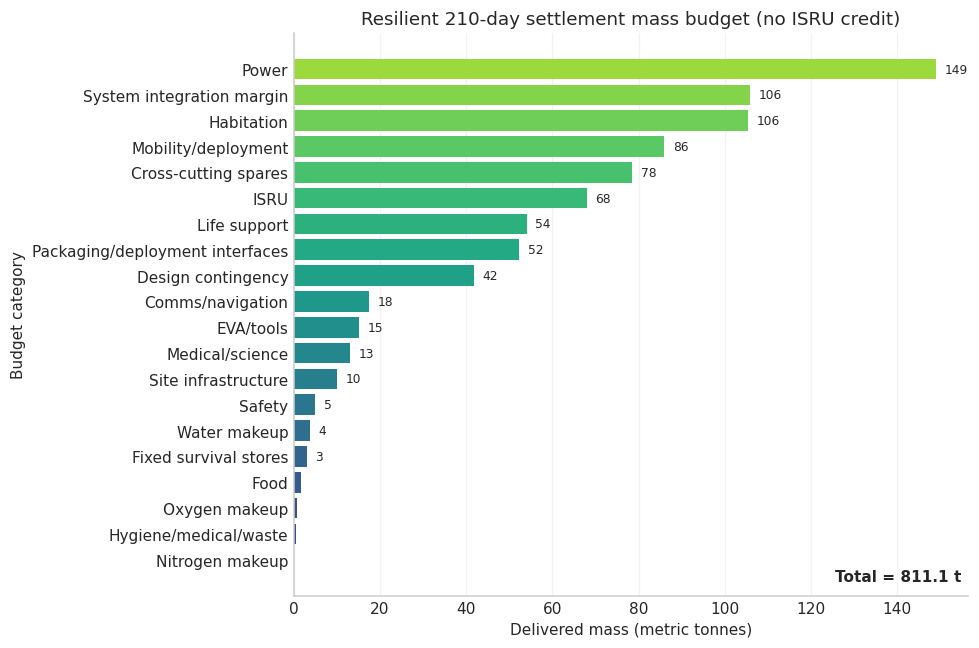

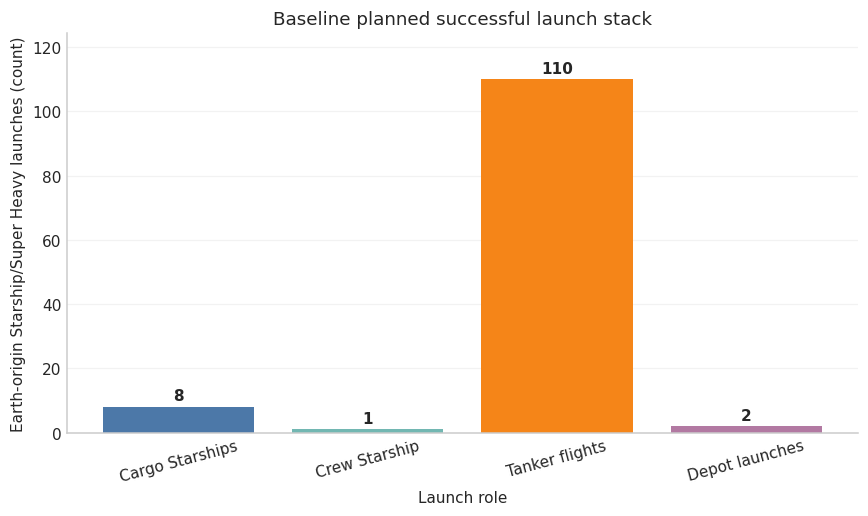

,launches
Cargo Starships,8
Crew Starship,1
Tanker flights,110
Depot launches,2


In [11]:
# Mass budget figure
mass_plot = baseline_budget.groupby("category", as_index=False).mass_t.sum().sort_values("mass_t")
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.viridis(np.linspace(0.18, 0.85, len(mass_plot)))
ax.barh(mass_plot.category, mass_plot.mass_t, color=colors)
ax.set_title("Resilient 210-day settlement mass budget (no ISRU credit)")
ax.set_xlabel("Delivered mass (metric tonnes)")
ax.set_ylabel("Budget category")
ax.grid(axis="x", alpha=0.25); ax.grid(axis="y", visible=False)
for y, v in enumerate(mass_plot.mass_t):
    if v >= 2:
        ax.text(v + 2, y, f"{v:.0f}", va="center", fontsize=8)
ax.text(0.99, 0.02, f"Total = {baseline_budget.mass_t.sum():.1f} t", transform=ax.transAxes,
        ha="right", va="bottom", fontweight="bold")
fig.tight_layout()
fig.savefig("mass_budget.png", dpi=160, bbox_inches="tight")
plt.show()

# Launch-stack breakdown
launch_categories = pd.Series({"Cargo Starships": baseline_launches["cargo"], "Crew Starship": baseline_launches["crew"],
                               "Tanker flights": baseline_launches["tankers"], "Depot launches": baseline_launches["depots"]})
fig, ax = plt.subplots(figsize=(8, 4.8))
bar_colors = ["#4C78A8", "#72B7B2", "#F58518", "#B279A2"]
ax.bar(launch_categories.index, launch_categories.values, color=bar_colors)
ax.set_title("Baseline planned successful launch stack")
ax.set_ylabel("Earth-origin Starship/Super Heavy launches (count)")
ax.set_xlabel("Launch role")
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.25); ax.grid(axis="x", visible=False)
for i, v in enumerate(launch_categories.values):
    ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
ax.set_ylim(0, max(launch_categories.values) * 1.13)
fig.tight_layout()
fig.savefig("launch_stack.png", dpi=160, bbox_inches="tight")
plt.show()
launch_categories.to_frame("launches")

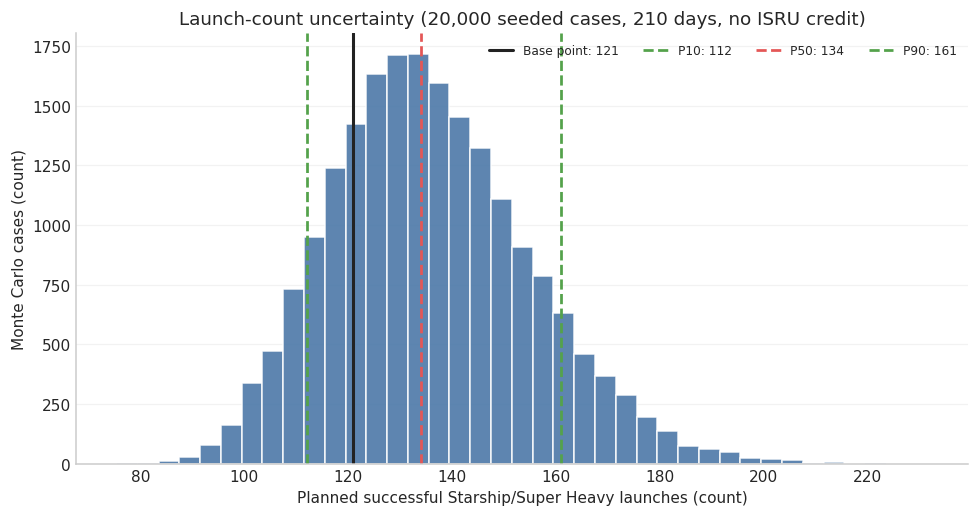

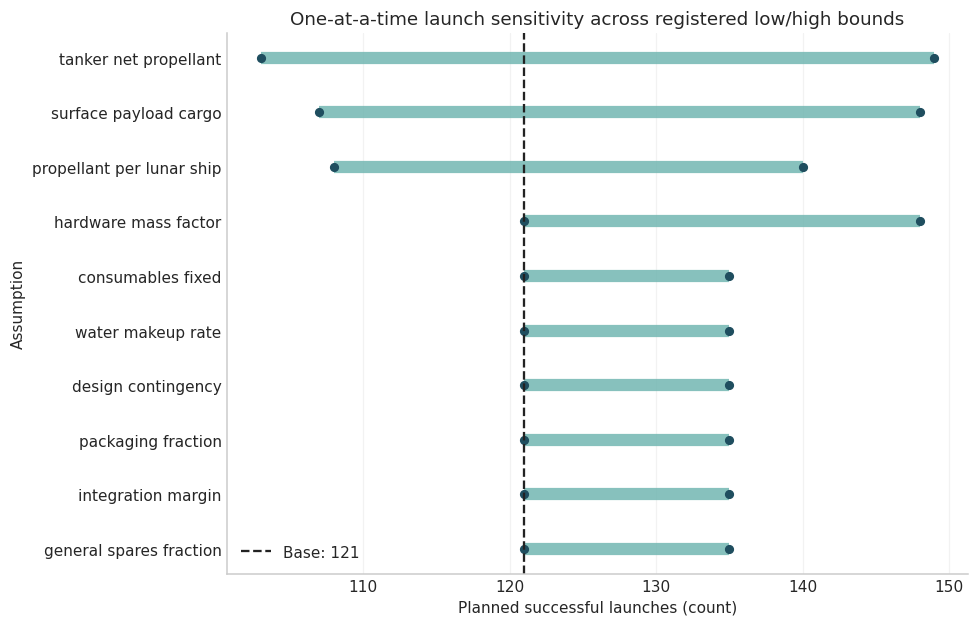

,parameter,low total,base total,high total,range launches
4,general_spares_fraction,121,121,135,14
5,integration_margin,121,121,135,14
6,packaging_fraction,121,121,135,14
7,design_contingency,121,121,135,14
8,water_makeup_rate,121,121,135,14
9,consumables_fixed,121,121,135,14
3,hardware_mass_factor,121,121,148,27
2,propellant_per_lunar_ship,108,121,140,32
1,surface_payload_cargo,148,121,107,41
0,tanker_net_propellant,149,121,103,46


In [12]:
# Launch-count uncertainty distribution
fig, ax = plt.subplots(figsize=(9, 4.8))
bins = np.arange(mc_results.total.min() - 0.5, mc_results.total.max() + 1.5, 4)
ax.hist(mc_results.total, bins=bins, color="#4C78A8", edgecolor="white", alpha=0.9)
ax.axvline(baseline_launches["total"], color="#222222", linewidth=2, label=f"Base point: {baseline_launches['total']}")
for q, color in zip([0.10, 0.50, 0.90], ["#54A24B", "#E45756", "#54A24B"]):
    val = int(quantiles.loc[q])
    ax.axvline(val, color=color, linestyle="--", linewidth=1.8, label=f"P{int(q*100)}: {val}")
ax.set_title(f"Launch-count uncertainty ({N_MC:,} seeded cases, 210 days, no ISRU credit)")
ax.set_xlabel("Planned successful Starship/Super Heavy launches (count)")
ax.set_ylabel("Monte Carlo cases (count)")
ax.legend(ncol=4, fontsize=8)
ax.grid(axis="y", alpha=0.25); ax.grid(axis="x", visible=False)
fig.tight_layout()
fig.savefig("launch_uncertainty.png", dpi=160, bbox_inches="tight")
plt.show()

# Tornado chart: widest one-at-a-time integer launch ranges.
tornado = sensitivity.head(10).sort_values("range launches")
fig, ax = plt.subplots(figsize=(9, 5.8))
y = np.arange(len(tornado))
for yi, row in enumerate(tornado.itertuples(index=False)):
    lo, hi = sorted([getattr(row, "_1"), getattr(row, "_3")]) if False else (min(row[1], row[3]), max(row[1], row[3]))
    ax.hlines(yi, lo, hi, color="#72B7B2", linewidth=8, alpha=0.85)
    ax.plot([row[1], row[3]], [yi, yi], "o", color="#1F4E5F", markersize=5)
ax.axvline(base_la["total"], color="#222222", linestyle="--", label=f"Base: {base_la['total']}")
ax.set_yticks(y, [p.replace("_", " ") for p in tornado.parameter])
ax.set_title("One-at-a-time launch sensitivity across registered low/high bounds")
ax.set_xlabel("Planned successful launches (count)")
ax.set_ylabel("Assumption")
ax.legend()
ax.grid(axis="x", alpha=0.25); ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig("sensitivity_tornado.png", dpi=160, bbox_inches="tight")
plt.show()
tornado[["parameter", "low total", "base total", "high total", "range launches"]]

In [14]:
# Write tabular deliverables.
assumptions.to_csv("ASSUMPTIONS.csv", index=False)
manifest_out = baseline_manifest.copy()
flight_mass_map = manifest_out.groupby("flight").mass_t.sum()
manifest_out["flight_total_mass_t"] = manifest_out.flight.map(flight_mass_map)
manifest_out["flight_capacity_t"] = manifest_out.flight_type.map({"cargo": av("surface_payload_cargo"), "crew": av("surface_payload_crew")})
manifest_out["flight_remaining_capacity_t"] = manifest_out.flight_capacity_t - manifest_out.flight_total_mass_t
manifest_out.to_csv("LAUNCH_MANIFEST.csv", index=False)

# A compact standalone implementation reads the exported registry and reproduces baseline accounting.
model_source = '''"""Reproduce the baseline lunar-settlement launch arithmetic from ASSUMPTIONS.csv."""
import math
import pandas as pd
ITEM_SPECS = __ITEMS__

def values(path="ASSUMPTIONS.csv"):
    return pd.read_csv(path).set_index("parameter")["base"].astype(float).to_dict()

def delivered_mass(days=210, policy="no_credit", v=None):
    v = values() if v is None else v
    hardware = sum(q*m for _,_,q,m,_,_ in ITEM_SPECS) * v["hardware_mass_factor"]
    if policy == "no_credit": commission, replacement = math.inf, 0.0
    else:
        prefix = "partial" if policy == "partial" else "mature"
        commission, replacement = v[prefix+"_isru_commission_day"], v[prefix+"_isru_replacement"]
    retained = days - max(0, days-commission)*replacement
    cons = (v["crew_size"]*days*(v["food_rate"]+v["nitrogen_makeup_rate"]+v["hygiene_medical_rate"])
            + v["crew_size"]*retained*(v["water_makeup_rate"]+v["oxygen_makeup_rate"]))/1000 + v["consumables_fixed"]
    subtotal = hardware*(1+v["design_contingency"]+v["general_spares_fraction"]) + cons
    return subtotal*(1+v["packaging_fraction"])*(1+v["integration_margin"])

def crew_load(v):
    priority={"EVA/tools","Medical/science","Comms/navigation","Safety"}
    masses=sorted(m*v["hardware_mass_factor"] for _,cat,q,m,_,_ in ITEM_SPECS if cat in priority for _ in range(int(q)))
    load=0.0
    for mass in masses:
        if load+mass <= v["surface_payload_crew"]+1e-9: load += mass
    return load

def launch_accounting(days=210, policy="no_credit"):
    v=values(); mass=delivered_mass(days,policy,v)
    cargo=math.ceil((mass-crew_load(v))/v["surface_payload_cargo"]-1e-12); crew=int(v["crew_starships"]); lunar=cargo+crew
    prop=v["propellant_per_lunar_ship"]*(1+v["propellant_reserve"])/(1-v["transfer_loss"]-v["boiloff"])
    tankers=math.ceil(lunar*prop/v["tanker_net_propellant"]-1e-12)
    depots=max(math.ceil(prop/v["depot_capacity"]-1e-12), math.ceil(lunar/v["depot_reuse_cycles"]-1e-12))
    return {"delivered_mass_t":mass,"cargo":cargo,"crew":crew,"tankers":tankers,"depots":depots,"total":cargo+crew+tankers+depots}

if __name__ == "__main__": print(launch_accounting())
'''.replace("__ITEMS__", repr(item_specs))
Path("lunar_settlement_model.py").write_text(model_source, encoding="utf-8")

def markdown_table(df, decimals=2):
    def fmt(x):
        if isinstance(x, (float, np.floating)): return f"{x:.{decimals}f}"
        return str(x)
    headers = [str(c) for c in df.columns]
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"]*len(headers)) + " |"]
    lines += ["| " + " | ".join(fmt(x) for x in row) + " |" for row in df.itertuples(index=False, name=None)]
    return "\n".join(lines)

p10, p50, p90 = [int(quantiles.loc[q]) for q in [0.10, 0.50, 0.90]]
expected_attempts = baseline_launches["total"] / av("launch_success_probability")
mission_md = markdown_table(mission_case_table[["mission case","delivered mass t","cargo","crew","tankers","depots","total"]], 1)
scenario_md = markdown_table(scenario_table[["scenario","ISRU policy","delivered mass t","cargo","crew","tankers","depots","total"]], 1)
isru_md = markdown_table(budget_comparison, 2)
top_md = markdown_table(top_five[["parameter","low total","base total","high total","range launches","Spearman rho"]], 2)
crew_carried = float(flight_summary.loc[flight_summary.flight == "Crew-1", "manifested_mass_t"].iloc[0])

report = f'''# Lunar south-pole settlement launch estimate

> **Baseline: 121 successful Starship launches = 9 cargo/crew Starships + 110 tanker flights + 2 depot launches. Plausible range: {p10}–{p90}.**

The decision baseline is four people for 210 days (180 plus 30 reserve) with **no ISRU survival credit**. It uses 8 cargo Starships and 1 crew Starship. There is no non-Starship launch dependency, so the Starship and all-launch-vehicle totals are both 121.

## Launch arithmetic

- Settlement inventory: **{baseline_budget.mass_t.sum():.1f} t** delivered.
- Lunar-bound vehicles: **8 cargo + 1 crew = 9**.
- Depot throughput per lunar vehicle: **{baseline_launches['propellant_per_lunar_ship_t']:.0f} t**, including assumed reserve, loss, and boiloff.
- Tankers: `ceil(9 × {baseline_launches['propellant_per_lunar_ship_t']:.1f} / {av('tanker_net_propellant'):.0f}) = 110`.
- Depots: max(capacity requirement, reuse-cycle requirement) = **2**.
- Total: `8 + 1 + 110 + 2 = 121` planned successful launches.

## Infrastructure-only and crew-inclusive

- Infrastructure-only all-cargo build: **121 = 9 cargo + 110 tanker + 2 depot**.
- Crew-inclusive: **121 = 8 cargo + 1 crew + 110 tanker + 2 depot**.
- The crew vehicle substitutes for one cargo vehicle and carries {crew_carried:.1f} t of inventory.

## Strict 180-day and reserve results

{mission_md}

The 30 extra days add {baseline_budget.mass_t.sum()-build_mass_budget(180,'no_credit').mass_t.sum():.1f} t but do not cross a launch boundary.

## ISRU policies

{isru_md}

Partial credit starts after day 60 at 50% water/oxygen replacement; mature credit starts after day 30 at 80%. No policy credits food, nitrogen, hygiene/medical, fixed contingency, or pre-commissioning stores. The headline uses no credit.

## Conservative, baseline, and optimistic corners

{scenario_md}

Corners compound all bounds and are not percentiles. The seeded 20,000-case no-credit Monte Carlo gives **P10/P50/P90 = {p10}/{p50}/{p90}**; {p10}–{p90} is the stated plausible range.

![Mass budget](mass_budget.png)

![Launch stack](launch_stack.png)

![Launch uncertainty](launch_uncertainty.png)

![Sensitivity](sensitivity_tornado.png)

## Top five drivers

{top_md}

Evidence that would most reduce uncertainty:

1. Repeated demonstration of net tanker propellant delivered after transfer losses.
2. A closed lunar-landing design for usable surface payload and unloading interfaces.
3. Trajectory/reserve closure for propellant required per lunar-bound Starship.
4. Mass-mature power, habitation, mobility, and ISRU designs.
5. Reliability evidence supporting narrower spares and depot-reuse assumptions.

## Resilience basis

The inventory includes two isolatable habitats, duplicate airlocks, 2+1 life-support and water trains, dual emergency power, sectional solar/batteries, redundant communications, six suits, duplicate ISRU/feedstock equipment, rescue mobility, deployment machinery, workshops, medical caches, and explicit contingency, spares, packaging, and integration layers. These are conceptual allowances, not certified designs.

## Planned successes versus expected attempts

The headline is **planned successful launches**. As a separate illustration only, independent 97% success on every attempt implies `121 / 0.97 = {expected_attempts:.1f}` expected attempts. It is not added to the plan or Monte Carlo and does not represent correlated-failure risk.

## Dominant caveat and verification

No Starship performance input is claimed as verified. Tanker delivery and lunar payload dominate and each moves the answer by more than 40 launches across its registered range. This is an architecture-scale estimate, not a flight-certified manifest.

All {len(check_table)} automated checks pass: mass reconciliation, flight capacity, category sum, payload monotonicity, crew-size and duration monotonicity, no propellant/cargo double count, and complete infrastructure-only inventory.
'''
Path("REPORT.md").write_text(report, encoding="utf-8")

artifact_status = pd.DataFrame([(p, Path(p).stat().st_size) for p in [
    "ASSUMPTIONS.csv","LAUNCH_MANIFEST.csv","lunar_settlement_model.py","REPORT.md",
    "mass_budget.png","launch_stack.png","launch_uncertainty.png","sensitivity_tornado.png"]],
    columns=["artifact","bytes"])
artifact_status

,artifact,bytes
0,ASSUMPTIONS.csv,9653
1,LAUNCH_MANIFEST.csv,11599
2,lunar_settlement_model.py,4985
3,REPORT.md,4905
4,mass_budget.png,125950
5,launch_stack.png,67738
6,launch_uncertainty.png,68046
7,sensitivity_tornado.png,94853


In [15]:
# Validate exported artifacts without subprocesses.
exported_assumptions = pd.read_csv("ASSUMPTIONS.csv")
exported_manifest = pd.read_csv("LAUNCH_MANIFEST.csv")
model_ns = {"__name__": "exported_model"}
exec(compile(Path("lunar_settlement_model.py").read_text(encoding="utf-8"), "lunar_settlement_model.py", "exec"), model_ns)
exported_result = model_ns["launch_accounting"]()
report_text = Path("REPORT.md").read_text(encoding="utf-8")
export_checks = pd.DataFrame([
    ("Assumptions rows", len(exported_assumptions) == len(assumptions), f"{len(exported_assumptions)} rows"),
    ("Manifest mass", np.isclose(exported_manifest.mass_t.sum(), baseline_budget.mass_t.sum()), f"{exported_manifest.mass_t.sum():.3f} t"),
    ("Standalone model total", exported_result["total"] == 121, str(exported_result)),
    ("Report headline", report_text.startswith("# Lunar") and "Baseline: 121" in report_text, f"{len(report_text)} characters"),
], columns=["export check", "passed", "detail"])
print(f"Export verification: {export_checks.passed.sum()}/{len(export_checks)} passed")
export_checks

Export verification: 4/4 passed


,export check,passed,detail
0,Assumptions rows,True,89 rows
1,Manifest mass,True,811.129 t
2,Standalone model total,True,"{'delivered_mass_t': 811.1285892, 'cargo': 8, ..."
3,Report headline,True,4900 characters


# Decision summary

> **Baseline: 121 planned successful Starship/Super Heavy launches = 9 cargo/crew Starships + 110 tanker flights + 2 depot launches. Plausible range: 112–161 launches (Monte Carlo P10–P90; P50 134).**

**Launch arithmetic:** `8 cargo + 1 crew + 110 tanker + 2 depot = 121`. The crew-inclusive architecture has no non-Starship dependency, so its all-launch-vehicle total is also **121**. Repacking the same 811.1 t inventory without crew gives the infrastructure-only result `9 cargo + 110 tanker + 2 depot = 121`.

The strict 180-day case and the resilient 180+30-day case both require **121** launches at registered base assumptions; the reserve adds 1.2 t but does not cross an integer boundary. The headline grants **no ISRU consumables credit**. Compounded scenario corners span **56 optimistic to 357 conservative**, while the seeded 20,000-case uncertainty analysis gives the more decision-useful 112–161 plausible range.

**Dominant caveat:** no Starship performance value here is claimed as verified. Net tanker delivery and usable lunar-surface payload dominate the result; each changes the estimate by more than 40 launches across its registered bounds. The 121 figure counts planned successes, not attempts; a separate illustrative 97% independent success assumption implies 124.7 expected attempts.